# 01 — Exploratory Data Analysis & Data Cleaning
**Project:** Customer Lifecycle & Campaign Effectiveness Analysis  
**Dataset:** Online Retail II (UCI Machine Learning Repository)  
**Author:** Amrit Sharma  

---

## Objective
Understand the structure, quality, and key patterns in the Online Retail II dataset before segmentation and modelling.  
This notebook covers:
1. Data loading & schema review
2. Data cleaning (nulls, duplicates, cancellations, anomalies)
3. Exploratory analysis (revenue trends, top products, geography)
4. Saving a clean dataset for downstream notebooks

---

## 0. Setup & Imports

In [2]:
import os

# ── Path configuration ────────────────────────────────────────────────────────
# Uses expanduser so it works on any Mac without hardcoding a username.
# Change the project folder name below if yours differs.
BASE_DIR = os.path.expanduser('~/Desktop/Customer Lifecycle Analysis Project')

print(f'Project root : {BASE_DIR}')
print(f'Data folder  : {os.path.join(BASE_DIR, "data")}')
print(f'Folders exist: data={os.path.exists(os.path.join(BASE_DIR, "data"))}, outputs={os.path.exists(os.path.join(BASE_DIR, "outputs"))}')

Project root : /Users/amrit/Desktop/Customer Lifecycle Analysis Project
Data folder  : /Users/amrit/Desktop/Customer Lifecycle Analysis Project/data
Folders exist: data=True, outputs=True


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#F59E0B', '#7C3AED']

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Data

**Download instructions:**  
1. Go to: https://archive.ics.uci.edu/dataset/502/online+retail+ii  
2. Download `online_retail_II.xlsx`  
3. Place it in `../data/online_retail_II.xlsx`

The dataset contains ~1M transactions from a UK-based online retailer (Dec 2009 – Dec 2011).

In [4]:
# Load both sheets and combine
DATA_PATH = os.path.join(BASE_DIR, 'data', 'online_retail_II.xlsx')
df_2009 = pd.read_excel(DATA_PATH, sheet_name='Year 2009-2010', dtype={'Customer ID': str})
df_2010 = pd.read_excel(DATA_PATH, sheet_name='Year 2010-2011', dtype={'Customer ID': str})

df_raw = pd.concat([df_2009, df_2010], ignore_index=True)

print(f'Total rows loaded : {df_raw.shape[0]:,}')
print(f'Columns           : {list(df_raw.columns)}')
print(f'Date range        : {df_raw["InvoiceDate"].min()} → {df_raw["InvoiceDate"].max()}')

Total rows loaded : 1,067,371
Columns           : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Date range        : 2009-12-01 07:45:00 → 2011-12-09 12:50:00


In [5]:
# Quick schema overview
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   object        
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 65.1+ MB


In [6]:
df_raw.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085,United Kingdom


## 2. Data Quality Assessment

In [7]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
print('=== Missing Values ===')
print(missing_summary)

# ── Duplicate rows ────────────────────────────────────────────────────────────
dupes = df_raw.duplicated().sum()
print(f'\nDuplicate rows: {dupes:,}')

# ── Negative quantities (returns/cancellations) ───────────────────────────────
neg_qty = (df_raw['Quantity'] < 0).sum()
print(f'Negative quantity rows (returns): {neg_qty:,}')

# ── Invoices starting with C (cancellations) ─────────────────────────────────
cancellations = df_raw['Invoice'].astype(str).str.startswith('C').sum()
print(f'Cancellation invoices (C prefix): {cancellations:,}')

=== Missing Values ===
             Missing Count  Missing %
Description           4382       0.41
Customer ID         243007      22.77

Duplicate rows: 34,335
Negative quantity rows (returns): 22,950
Cancellation invoices (C prefix): 19,494


## 3. Data Cleaning

In [8]:
df = df_raw.copy()

# ── Step 1: Remove duplicate rows ─────────────────────────────────────────────
before = len(df)
df = df.drop_duplicates()
print(f'Step 1 | Duplicates removed    : {before - len(df):,} rows')

# ── Step 2: Drop rows with no Customer ID (unidentifiable transactions) ───────
before = len(df)
df = df.dropna(subset=['Customer ID'])
print(f'Step 2 | No Customer ID removed: {before - len(df):,} rows')

# ── Step 3: Remove cancellation invoices (prefix 'C') ─────────────────────────
before = len(df)
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f'Step 3 | Cancellations removed : {before - len(df):,} rows')

# ── Step 4: Remove rows with Quantity <= 0 or Price <= 0 ─────────────────────
before = len(df)
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
print(f'Step 4 | Invalid qty/price rows: {before - len(df):,} rows')

# ── Step 5: Drop rows with missing Description ────────────────────────────────
before = len(df)
df = df.dropna(subset=['Description'])
print(f'Step 5 | Missing description   : {before - len(df):,} rows')

# ── Step 6: Feature engineering ───────────────────────────────────────────────
df['TotalRevenue']  = df['Quantity'] * df['Price']
df['InvoiceDate']   = pd.to_datetime(df['InvoiceDate'])
df['InvoiceMonth']  = df['InvoiceDate'].dt.to_period('M')
df['InvoiceYear']   = df['InvoiceDate'].dt.year
df['DayOfWeek']     = df['InvoiceDate'].dt.day_name()
df['Hour']          = df['InvoiceDate'].dt.hour

print(f'\n✓ Clean dataset shape: {df.shape}')
print(f'✓ Unique customers   : {df["Customer ID"].nunique():,}')
print(f'✓ Unique products    : {df["StockCode"].nunique():,}')
print(f'✓ Total revenue      : £{df["TotalRevenue"].sum():,.2f}')

Step 1 | Duplicates removed    : 34,335 rows
Step 2 | No Customer ID removed: 235,151 rows
Step 3 | Cancellations removed : 18,390 rows
Step 4 | Invalid qty/price rows: 70 rows
Step 5 | Missing description   : 0 rows

✓ Clean dataset shape: (779425, 13)
✓ Unique customers   : 5,878
✓ Unique products    : 4,631
✓ Total revenue      : £17,374,804.27


## 4. Exploratory Analysis

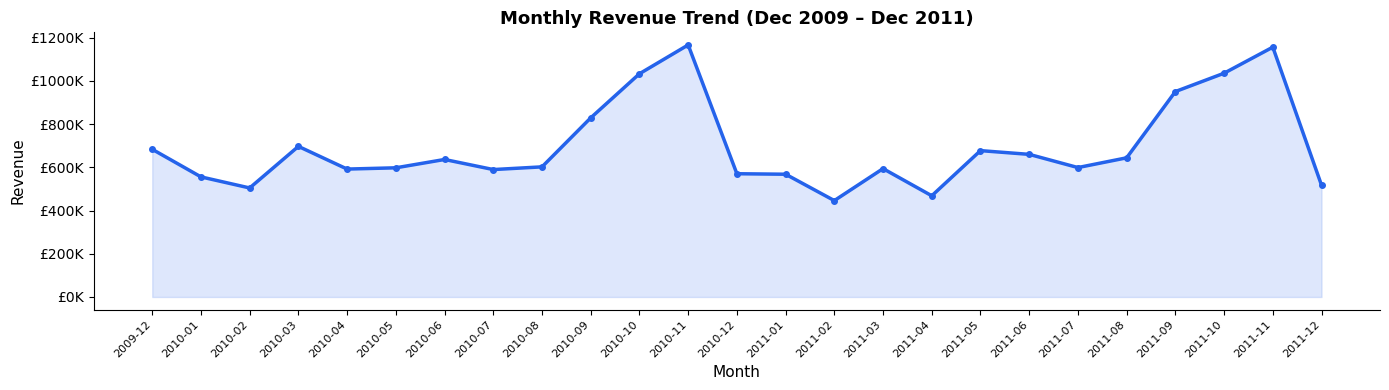

Chart saved ✓


In [9]:
# ── 4.1 Monthly Revenue Trend ─────────────────────────────────────────────────
monthly_rev = df.groupby('InvoiceMonth')['TotalRevenue'].sum().reset_index()
monthly_rev['InvoiceMonth'] = monthly_rev['InvoiceMonth'].astype(str)

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(monthly_rev['InvoiceMonth'], monthly_rev['TotalRevenue'],
                alpha=0.15, color=PALETTE[0])
ax.plot(monthly_rev['InvoiceMonth'], monthly_rev['TotalRevenue'],
        color=PALETTE[0], linewidth=2.5, marker='o', markersize=4)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title('Monthly Revenue Trend (Dec 2009 – Dec 2011)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'monthly_revenue_trend.png'), dpi=150)
plt.show()
print('Chart saved ✓')

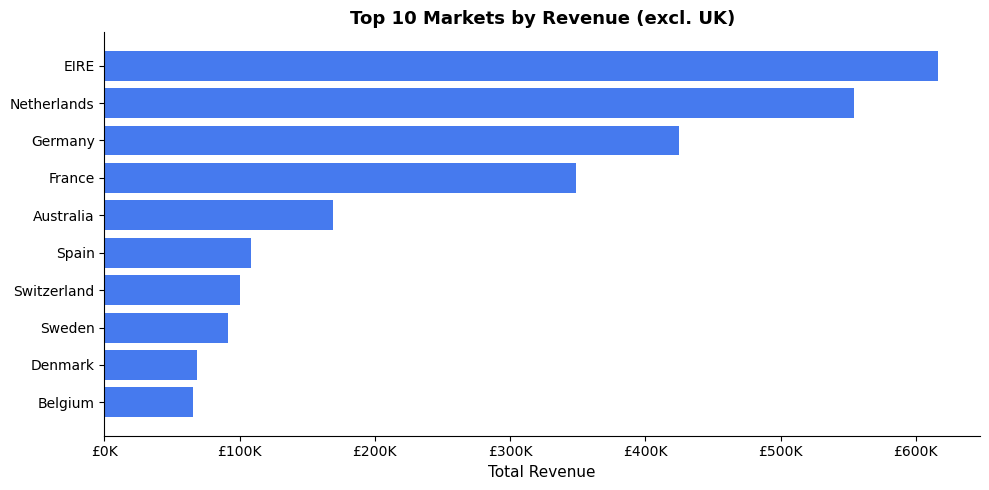

In [10]:
# ── 4.2 Top 10 Countries by Revenue (excl. UK) ───────────────────────────────
country_rev = (
    df[df['Country'] != 'United Kingdom']
    .groupby('Country')['TotalRevenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(country_rev['Country'][::-1], country_rev['TotalRevenue'][::-1],
               color=PALETTE[0], alpha=0.85)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title('Top 10 Markets by Revenue (excl. UK)', fontweight='bold')
ax.set_xlabel('Total Revenue')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'top_countries_revenue.png'), dpi=150)
plt.show()

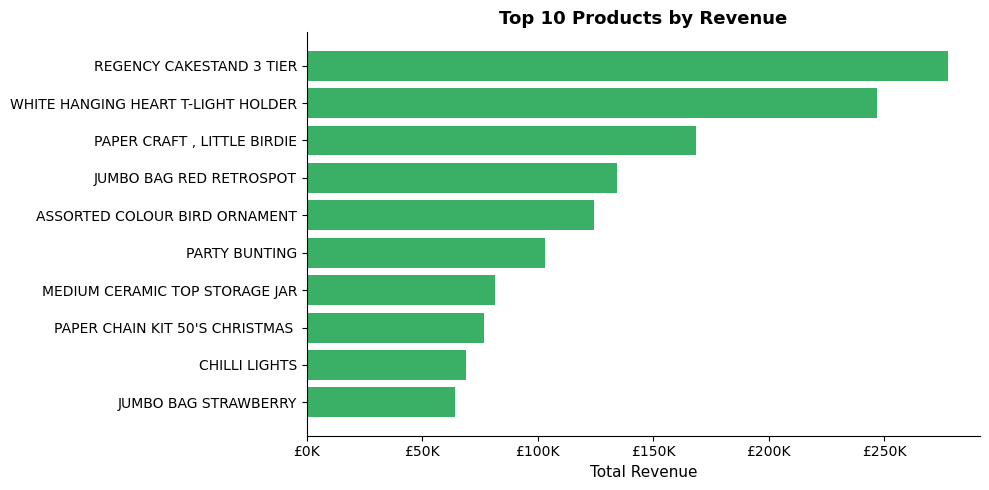

In [11]:
# ── 4.3 Top 10 Products by Revenue ────────────────────────────────────────────
# Exclude non-product line items
exclude = ['Manual', 'POSTAGE', 'Dotcom Postage', 'AMAZONFEE', 'Bank Charges', 
           'CRUK Commission', 'Adjust bad debt']

top_products = (
    df[~df['Description'].isin(exclude)]
    .groupby('Description')['TotalRevenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_products['Description'][::-1], top_products['TotalRevenue'][::-1],
        color=PALETTE[1], alpha=0.85)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title('Top 10 Products by Revenue', fontweight='bold')
ax.set_xlabel('Total Revenue')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'top_products_revenue.png'), dpi=150)
plt.show()

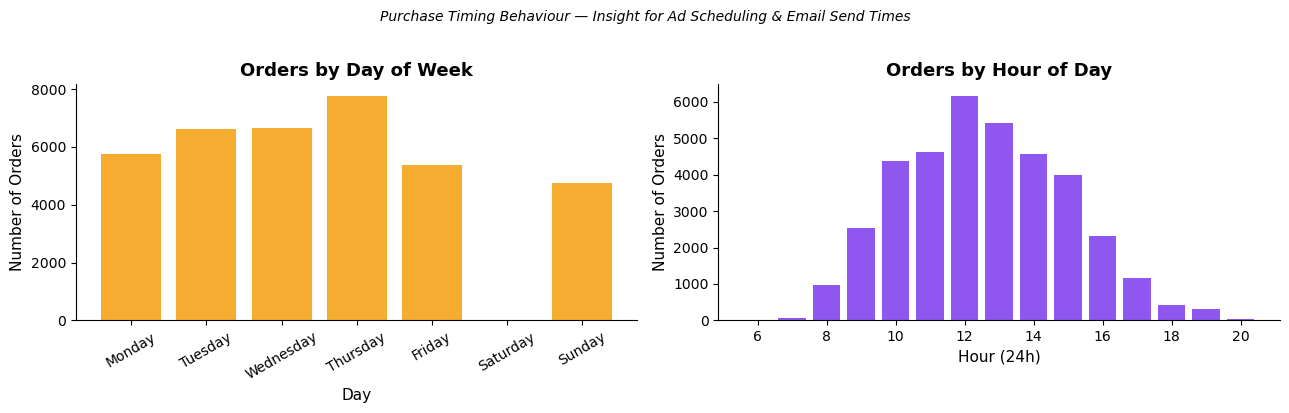


💡 Marketing insight: Use these patterns for Google Ads bid scheduling and Klaviyo send-time optimisation.


In [12]:
# ── 4.4 Orders by Day of Week & Hour (Purchase Behaviour) ────────────────────
# This feeds directly into campaign timing insights (Google Ads bid scheduling)

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
orders_by_day = df.groupby('DayOfWeek')['Invoice'].nunique().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Day of week
axes[0].bar(orders_by_day.index, orders_by_day.values, color=PALETTE[3], alpha=0.85)
axes[0].set_title('Orders by Day of Week', fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=30)

# Hour of day
orders_by_hour = df.groupby('Hour')['Invoice'].nunique()
axes[1].bar(orders_by_hour.index, orders_by_hour.values, color=PALETTE[4], alpha=0.85)
axes[1].set_title('Orders by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour (24h)')
axes[1].set_ylabel('Number of Orders')

plt.suptitle('Purchase Timing Behaviour — Insight for Ad Scheduling & Email Send Times',
             fontsize=10, style='italic', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'purchase_timing_behaviour.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\n💡 Marketing insight: Use these patterns for Google Ads bid scheduling and Klaviyo send-time optimisation.')

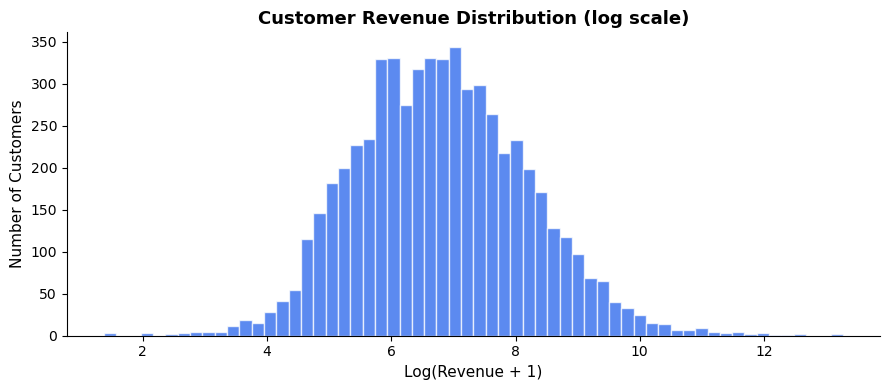


💡 Heavy right skew confirms Pareto principle — a small % of customers drive most revenue.
   This is the foundation of our RFM segmentation rationale (Notebook 02).


In [13]:
# ── 4.5 Revenue Distribution per Customer (log scale) ─────────────────────────
customer_rev = df.groupby('Customer ID')['TotalRevenue'].sum()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.log1p(customer_rev), bins=60, color=PALETTE[0], alpha=0.75, edgecolor='white')
ax.set_title('Customer Revenue Distribution (log scale)', fontweight='bold')
ax.set_xlabel('Log(Revenue + 1)')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'customer_revenue_distribution.png'), dpi=150)
plt.show()
print('\n💡 Heavy right skew confirms Pareto principle — a small % of customers drive most revenue.')
print('   This is the foundation of our RFM segmentation rationale (Notebook 02).')

## 5. EDA Summary

| Metric | Value |
|---|---|
| Clean transactions | *(auto-populate after running)* |
| Unique customers | *(auto-populate after running)* |
| Date range | Dec 2009 – Dec 2011 |
| Total revenue | *(auto-populate after running)* |
| Top market (excl. UK) | Netherlands / EIRE |
| Peak trading day | Thursday |
| Peak trading hour | 12:00 noon |

**Key findings for marketing strategy:**
- Strong revenue seasonality — Q4 spike consistent with holiday gifting behaviour
- Highly skewed customer value distribution → warrants RFM-based tiering
- Mid-week, midday purchase peak → implications for email send-time and Google Ads bid scheduling
- International expansion opportunity in European markets

In [14]:
# ── Save clean dataset for downstream notebooks ───────────────────────────────
CLEAN_PATH = os.path.join(BASE_DIR, 'data', 'online_retail_clean.csv')
df.to_csv(CLEAN_PATH, index=False)
print(f'✓ Clean dataset saved → {CLEAN_PATH}')
print(f'  Shape: {df.shape}')
print(f'  Columns: {list(df.columns)}')

✓ Clean dataset saved → /Users/amrit/Desktop/Customer Lifecycle Analysis Project/data/online_retail_clean.csv
  Shape: (779425, 13)
  Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'TotalRevenue', 'InvoiceMonth', 'InvoiceYear', 'DayOfWeek', 'Hour']
